## ANOVA de una vía

**Ejemplo Práctico:** Comparación de Niveles de Hemoglobina Glicosilada (HbA1c)

Escenario Clínico: Supongamos un estudio donde queremos evaluar si el nivel promedio de HbA1c difiere entre pacientes que siguen tres tipos de dietas: Mediterránea, Baja en Carbohidratos y Estándar.

Paso 1: Definición de Hipótesis
- $H_0$: Las medias de HbA1c son iguales en los tres grupos de dieta ($\mu_1 = \mu_2 = \mu_3$).
- $H_1$: Al menos una de las medias es diferente.

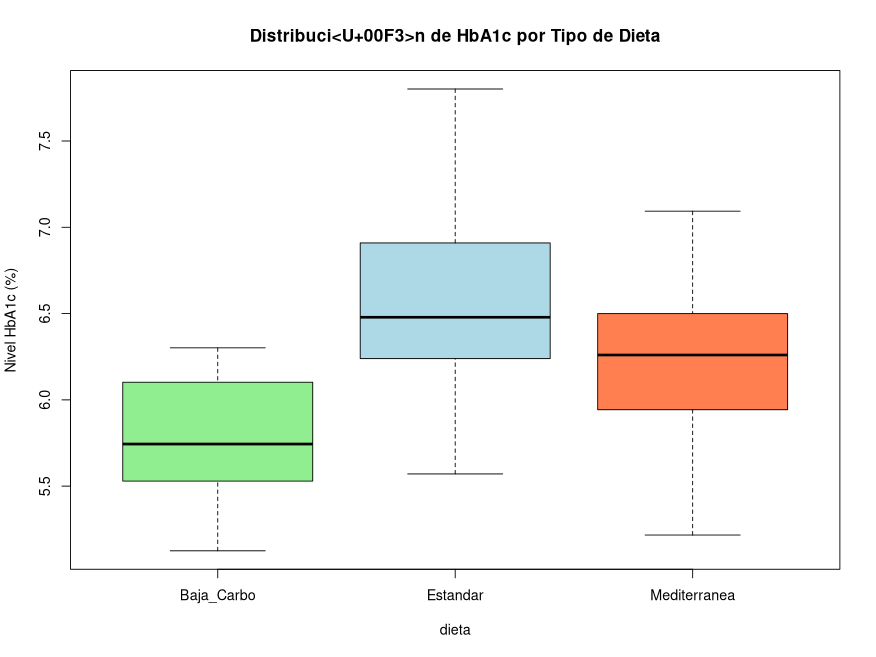

            Df Sum Sq Mean Sq F value   Pr(>F)    
dieta        2  6.284  3.1419   13.93 1.19e-05 ***
Residuals   57 12.857  0.2256                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [11]:
# 1. Creación de datos simulados
set.seed(123)
datos_dieta <- data.frame(
  dieta = factor(rep(c("Mediterranea", "Baja_Carbo", "Estandar"), each = 20)),
  hba1c = c(rnorm(20, 6.2, 0.5), rnorm(20, 5.8, 0.4), rnorm(20, 6.5, 0.6))
)

# 2. Visualización inicial
# Un boxplot permite observar la distribución y posibles diferencias
boxplot(hba1c ~ dieta, data = datos_dieta, 
        main = "Distribución de HbA1c por Tipo de Dieta",
        ylab = "Nivel HbA1c (%)", col = c("lightgreen", "lightblue", "coral"))

# 3. Ejecución del ANOVA
modelo_anova <- aov(hba1c ~ dieta, data = datos_dieta)

# 4. Resumen de resultados (Cálculo de F y p)
summary(modelo_anova)

In [12]:
# Post-hoc test to identify which diets differ significantly
TukeyHSD(modelo_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = hba1c ~ dieta, data = datos_dieta)

$dieta
                              diff        lwr        upr     p adj
Estandar-Baja_Carbo      0.7843940  0.4229857 1.14580231 0.0000077
Mediterranea-Baja_Carbo  0.4913148  0.1299065 0.85272307 0.0050976
Mediterranea-Estandar   -0.2930792 -0.6544875 0.06832907 0.1338061


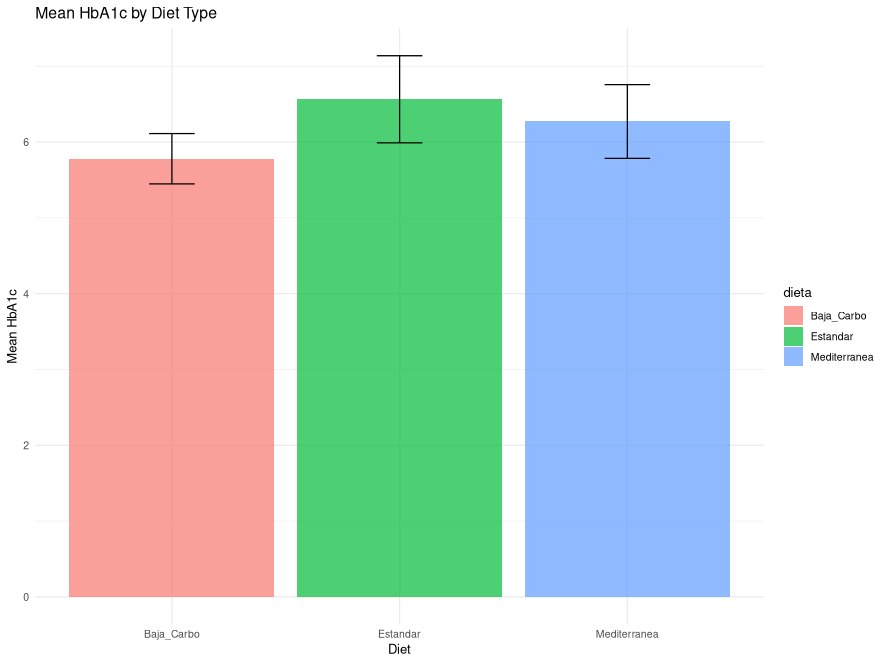

In [13]:
# Visualize mean HbA1c by diet group with error bars
library(dplyr)
library(ggplot2)

datos_dieta %>%
  group_by(dieta) %>%
  summarise(mean_hba1c = mean(hba1c), sd_hba1c = sd(hba1c)) %>%
  ggplot(aes(x = dieta, y = mean_hba1c, fill = dieta)) +
  geom_col(alpha = 0.7) +
  geom_errorbar(aes(ymin = mean_hba1c - sd_hba1c, ymax = mean_hba1c + sd_hba1c), width = 0.2) +
  labs(title = "Mean HbA1c by Diet Type", x = "Diet", y = "Mean HbA1c") +
  theme_minimal()

In [14]:
# Save the plot as a PNG file
ggsave("hba1c_by_diet.png", width = 8, height = 6, dpi = 300)

### Escenario Clínico: Evaluación de Terapias Hipolipemiantes

El objetivo es determinar si existe una diferencia estadísticamente significativa en la reducción del colesterol (variable dependiente continua) entre cinco grupos de tratamiento (variable independiente categórica o factor).
Este dataset emula un ensayo clínico diseñado para reducir los niveles de colesterol LDL mediante cinco terapias distintas.

In [15]:
# Instalación y carga de librerías necesarias
if(!require(multcomp)) install.packages("multcomp")
library(multcomp)
library(ggplot2)

# Carga del dataset real
data(cholesterol)
# Exploración de la estructura: 5 niveles (1st_drug...5th_drug)
str(cholesterol)

'data.frame':	50 obs. of  2 variables:
 $ trt     : Factor w/ 5 levels "1time","2times",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ response: num  3.86 10.39 5.91 3.06 7.72 ...


Paso 2: Análisis Exploratorio de Datos (EDA)

Antes del cálculo, es imperativo visualizar la dispersión. El gráfico de cajas (boxplot) permite identificar visualmente diferencias en las medianas y la presencia de valores atípicos.

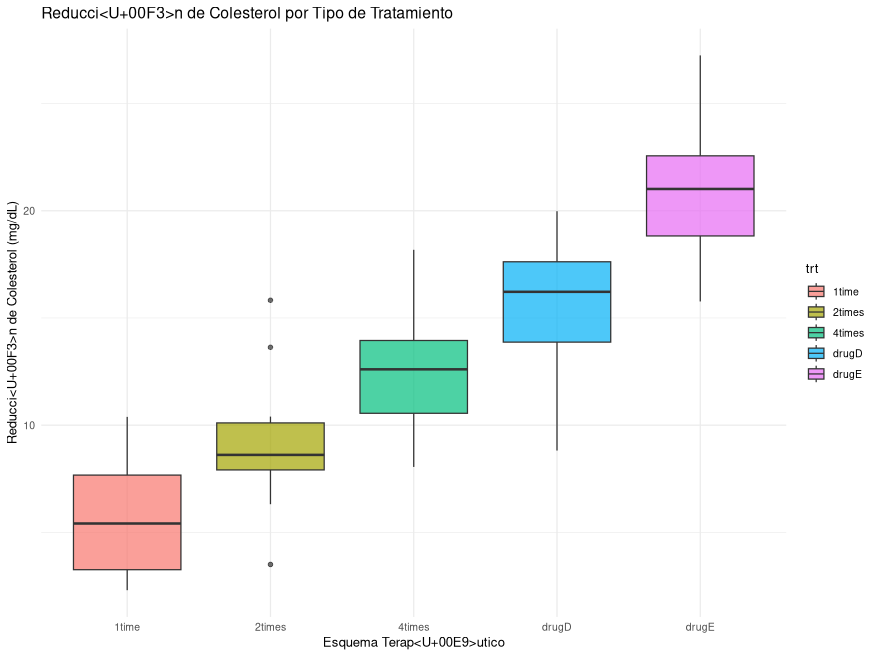

In [16]:
ggplot(cholesterol, aes(x = trt, y = response, fill = trt)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "Reducción de Colesterol por Tipo de Tratamiento",
       x = "Esquema Terapéutico", y = "Reducción de Colesterol (mg/dL)")

In [17]:
# Ajuste del modelo lineal
fit <- aov(response ~ trt, data = cholesterol)

# Resumen estadístico
summary(fit)

            Df Sum Sq Mean Sq F value   Pr(>F)    
trt          4 1351.4   337.8   32.43 9.82e-13 ***
Residuals   45  468.8    10.4                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Paso 4: Interpretación de Resultados CríticosAl ejecutar el resumen, obtendremos el Valor F y el Valor p:Valor F (F-statistic): Representa la razón de varianzas ($MS_{Between} / MS_{Within}$). Un valor F elevado indica que la variabilidad entre los fármacos es mucho mayor que la variabilidad biológica intragrupo.  Valor p (Pr(>F)): Es la probabilidad de observar estos resultados si la hipótesis nula fuera cierta ($H_0: \mu_1 = \mu_2 = \dots = \mu_5$). Si $p < 0.05$, se concluye que al menos un tratamiento difiere significativamente de los demás.  

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = response ~ trt, data = cholesterol)

$trt
                  diff        lwr       upr     p adj
2times-1time   3.44300 -0.6582817  7.544282 0.1380949
4times-1time   6.59281  2.4915283 10.694092 0.0003542
drugD-1time    9.57920  5.4779183 13.680482 0.0000003
drugE-1time   15.16555 11.0642683 19.266832 0.0000000
4times-2times  3.14981 -0.9514717  7.251092 0.2050382
drugD-2times   6.13620  2.0349183 10.237482 0.0009611
drugE-2times  11.72255  7.6212683 15.823832 0.0000000
drugD-4times   2.98639 -1.1148917  7.087672 0.2512446
drugE-4times   8.57274  4.4714583 12.674022 0.0000037
drugE-drugD    5.58635  1.4850683  9.687632 0.0030633



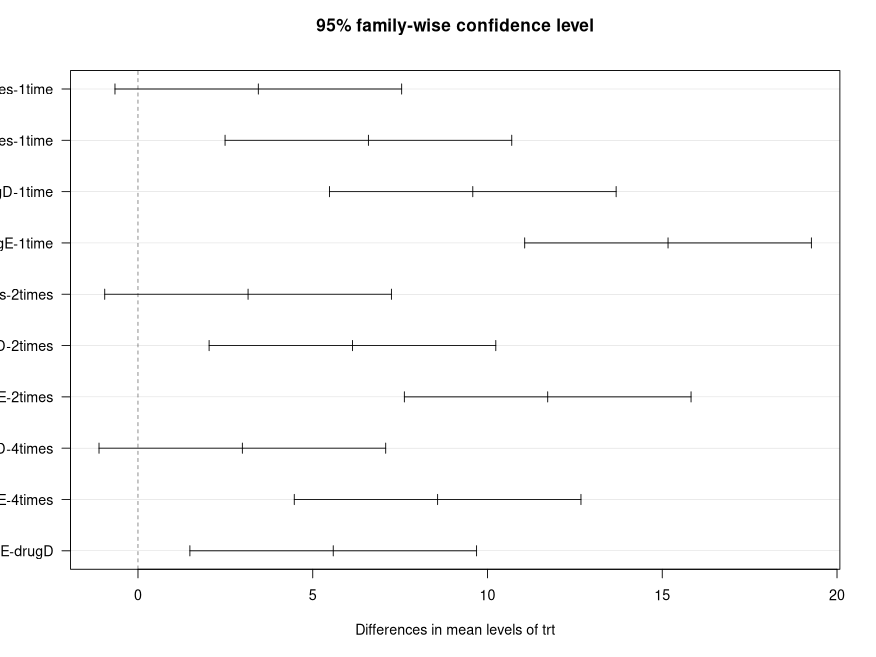

In [18]:
# Analisis Posthoc
# Comparaciones múltiples
post_hoc <- TukeyHSD(fit)
print(post_hoc)

# Visualización de los intervalos de confianza del post-hoc
plot(post_hoc, las = 1)

In [19]:
#  Extraer y mostrar comparaciones significativas de los resultados de Tukey HSD
post_hoc_df <- as.data.frame(post_hoc$trt)
post_hoc_df$comparison <- rownames(post_hoc_df)
post_hoc_df$significant <- post_hoc_df$`p adj` < 0.05
post_hoc_df[order(post_hoc_df$`p adj`), c("comparison", "diff", "p adj", "significant")]

                 comparison     diff        p adj significant
drugE-1time     drugE-1time 15.16555 1.347589e-12        TRUE
drugE-2times   drugE-2times 11.72255 2.270564e-09        TRUE
drugD-1time     drugD-1time  9.57920 3.456851e-07        TRUE
drugE-4times   drugE-4times  8.57274 3.724127e-06        TRUE
4times-1time   4times-1time  6.59281 3.541944e-04        TRUE
drugD-2times   drugD-2times  6.13620 9.610857e-04        TRUE
drugE-drugD     drugE-drugD  5.58635 3.063288e-03        TRUE
2times-1time   2times-1time  3.44300 1.380949e-01       FALSE
4times-2times 4times-2times  3.14981 2.050382e-01       FALSE
drugD-4times   drugD-4times  2.98639 2.512446e-01       FALSE

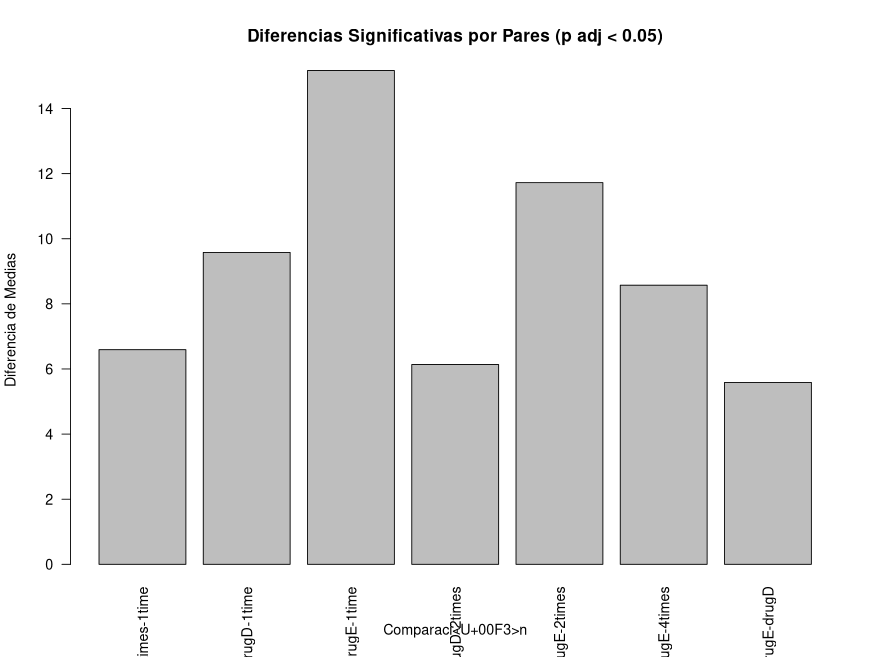

In [20]:
# Filtro y visualización de comparaciones por pares significativas
significant_comps <- post_hoc_df[post_hoc_df$significant, ]
barplot(significant_comps$diff, names.arg = significant_comps$comparison, 
        main = "Diferencias Significativas por Pares (p adj < 0.05)", 
        xlab = "Comparación", ylab = "Diferencia de Medias", las = 2)

In [21]:
# Resumen de las comparaciones significativas
print(significant_comps[, c("comparison", "diff", "p adj")])

               comparison     diff        p adj
4times-1time 4times-1time  6.59281 3.541944e-04
drugD-1time   drugD-1time  9.57920 3.456851e-07
drugE-1time   drugE-1time 15.16555 1.347589e-12
drugD-2times drugD-2times  6.13620 9.610857e-04
drugE-2times drugE-2times 11.72255 2.270564e-09
drugE-4times drugE-4times  8.57274 3.724127e-06
drugE-drugD   drugE-drugD  5.58635 3.063288e-03


In [23]:
# Summary table of significant pairwise comparisons
knitr::kable(significant_comps[, c("comparison", "diff", "lwr", "upr", "p adj")], 
             digits = 4,
             caption = "Significant Pairwise Comparisons with 95% Confidence Intervals")



Table: Significant Pairwise Comparisons with 95% Confidence Intervals

|             |comparison   |    diff|     lwr|     upr|  p adj|
|:------------|:------------|-------:|-------:|-------:|------:|
|4times-1time |4times-1time |  6.5928|  2.4915| 10.6941| 0.0004|
|drugD-1time  |drugD-1time  |  9.5792|  5.4779| 13.6805| 0.0000|
|drugE-1time  |drugE-1time  | 15.1655| 11.0643| 19.2668| 0.0000|
|drugD-2times |drugD-2times |  6.1362|  2.0349| 10.2375| 0.0010|
|drugE-2times |drugE-2times | 11.7226|  7.6213| 15.8238| 0.0000|
|drugE-4times |drugE-4times |  8.5727|  4.4715| 12.6740| 0.0000|
|drugE-drugD  |drugE-drugD  |  5.5863|  1.4851|  9.6876| 0.0031|